# SmartGrid  Benchmark global des variantes de features

Ce notebook charge le CSV de benchmark généré par `scripts/benchmark_feature_variants.py`, calculer les écarts **vs baseline**, classer tous les runs, puis sélectionne automatiquement les meilleurs candidats pour l'analyse détaillée.

**Usage conseillé**
1. Lancer d'abord la campagne de benchmark.
2. Ouvrir ce notebook dans `notebooks/experiments/`.
3. Exécuter toutes les cellules.
4. Noter les `run_id` / `run_dir` retenus pour le notebook d'analyse détaillée.


In [1]:
from __future__ import annotations

from pathlib import Path
import json
import math
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')
plt.style.use('seaborn-v0_8')


## 1. Détection robuste de la racine du projet et du CSV de benchmark

In [2]:
# Optionnel : force manuellement la racine si l'auto-détection échoue
MANUAL_PROJECT_ROOT = None
MANUAL_BENCHMARK_CSV = None


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / 'pyproject.toml').exists() and (p / 'src' / 'smartgrid').exists():
            return p
    raise FileNotFoundError(
        'Impossible de trouver la racine du projet. '        'Ouvre le notebook dans le repo smart-grid ou renseigne MANUAL_PROJECT_ROOT.'
    )


def find_benchmark_csv(project_root: Path) -> Path:
    if MANUAL_BENCHMARK_CSV:
        path = Path(MANUAL_BENCHMARK_CSV)
        if path.exists():
            return path
        raise FileNotFoundError(f'Benchmark CSV introuvable: {path}')

    candidates = [
        project_root / 'artifacts' / 'benchmarks' / 'consumption_feature_variants.csv',
        project_root / 'artifacts' / 'benchmarks' / 'feature_variants.csv',
    ]
    for c in candidates:
        if c.exists():
            return c

    found = sorted((project_root / 'artifacts').glob('**/*feature*variant*.csv'))
    if found:
        return found[-1]
    raise FileNotFoundError('Aucun CSV de benchmark trouvé dans artifacts/benchmarks.')


PROJECT_ROOT = Path(MANUAL_PROJECT_ROOT).resolve() if MANUAL_PROJECT_ROOT else find_project_root()
BENCHMARK_CSV = find_benchmark_csv(PROJECT_ROOT)

print('PROJECT_ROOT =', PROJECT_ROOT)
print('BENCHMARK_CSV =', BENCHMARK_CSV)


PROJECT_ROOT = /home/khalid/cours/m1/SmartGrid_Project/smart-grid
BENCHMARK_CSV = /home/khalid/cours/m1/SmartGrid_Project/smart-grid/artifacts/benchmarks/consumption_feature_variants.csv


## 2. Chargement et normalisation du benchmark

In [3]:
bench = pd.read_csv(BENCHMARK_CSV)
bench.columns = [str(c).strip() for c in bench.columns]

CONFIG_CANDIDATES = ['config_name', 'config', 'experiment_name', 'name']
RUN_ID_CANDIDATES = ['run_id']
RUN_DIR_CANDIDATES = ['run_dir']
EXPORTS_DIR_CANDIDATES = ['exports_dir']


def first_existing(cols: list[str], df: pd.DataFrame, default: str | None = None) -> str | None:
    for c in cols:
        if c in df.columns:
            return c
    return default


config_col = first_existing(CONFIG_CANDIDATES, bench)
run_id_col = first_existing(RUN_ID_CANDIDATES, bench)
run_dir_col = first_existing(RUN_DIR_CANDIDATES, bench)
exports_dir_col = first_existing(EXPORTS_DIR_CANDIDATES, bench)

if config_col is None:
    raise KeyError(f'Aucune colonne config trouvée parmi {CONFIG_CANDIDATES}. Colonnes disponibles: {list(bench.columns)}')

if run_id_col is None:
    # tente d'extraire un run_id à partir du run_dir si dispo
    if run_dir_col and run_dir_col in bench.columns:
        bench['run_id'] = bench[run_dir_col].astype(str).map(lambda x: Path(x).name if x and x != 'nan' else None)
        run_id_col = 'run_id'

bench = bench.rename(columns={config_col: 'config_name'})
if run_id_col:
    bench = bench.rename(columns={run_id_col: 'run_id'})
if run_dir_col:
    bench = bench.rename(columns={run_dir_col: 'run_dir'})
if exports_dir_col:
    bench = bench.rename(columns={exports_dir_col: 'exports_dir'})

bench.head()


,config_name,run_id,selected_analysis_day,count,MAE,RMSE,Bias(ME),MAPE%,InTolerance%,P95AbsError,P99AbsError,UnderShare%,OverShare%,Under_MAE,Over_MAE,SMAPE%,CorrAbsErr_vs_Real,RampingError_RMSE
0,configs/consumption/mlp_cyclical_weather_dynam...,consumption_mlp_20260410T050823Z,2025-11-29,2620,"6,459.650877","8,596.642852","-1,458.176664",2.644413,50.343511,"17,649.853125","24,546.609688",53.206107,46.793893,"7,440.713112","5,344.152707",2.664803,0.277475,"9,022.701263"
1,configs/consumption/mlp_cyclical_weather_dynam...,consumption_mlp_20260410T050835Z,2025-11-29,2620,"7,336.039516","9,886.186963","-5,629.782204",2.928782,47.862595,"20,297.925000","29,520.805937",77.251908,22.748092,"8,391.910303","3,750.330668",2.993388,0.337249,"8,735.353895"
2,configs/consumption/mlp_no_temp.yaml,consumption_mlp_20260410T050651Z,2025-11-29,2620,"18,645.271917","28,288.671432","-8,711.426199",7.161195,23.282443,"64,963.853125","104,271.243906",58.091603,41.908397,"23,546.172491","11,851.856002",7.530312,0.341714,"6,397.769072"
3,configs/consumption/mlp_baseline.yaml,consumption_mlp_20260410T050638Z,2025-11-29,2620,"19,882.709703","28,801.891416","-4,338.811206",7.681852,20.534351,"62,419.729687","103,114.591406",48.549618,51.450382,"24,945.119804","15,105.717382",7.962728,0.353230,"6,425.565168"
4,configs/consumption/mlp_cyclical.yaml,consumption_mlp_20260410T050718Z,2025-11-29,2620,"20,069.883668","30,740.222171","-12,977.416815",7.581370,22.557252,"74,316.365625","114,006.839375",66.183206,33.816794,"24,966.530353","10,486.604490",8.047734,0.396937,"6,331.255537"


In [6]:
metric_columns = [
    'MAE', 'RMSE', 'Bias(ME)', 'MAPE%', 'SMAPE%', 'InTolerance%',
    'P95AbsError', 'P99AbsError', 'UnderShare%', 'OverShare%',
    'Under_MAE', 'Over_MAE', 'CorrAbsErr_vs_Real', 'RampingError_RMSE'
]

available_metrics = [c for c in metric_columns if c in bench.columns]
missing_metrics = [c for c in metric_columns if c not in bench.columns]
print('Metrics disponibles:', available_metrics)
print('Metrics absentes:', missing_metrics)
print('Nombre de runs:', len(bench))
bench[ ['config_name'] + available_metrics ].copy()


Metrics disponibles: ['MAE', 'RMSE', 'Bias(ME)', 'MAPE%', 'SMAPE%', 'InTolerance%', 'P95AbsError', 'P99AbsError', 'UnderShare%', 'OverShare%', 'Under_MAE', 'Over_MAE', 'CorrAbsErr_vs_Real', 'RampingError_RMSE']
Metrics absentes: []
Nombre de runs: 10


,config_name,MAE,RMSE,Bias(ME),MAPE%,SMAPE%,InTolerance%,P95AbsError,P99AbsError,UnderShare%,OverShare%,Under_MAE,Over_MAE,CorrAbsErr_vs_Real,RampingError_RMSE
0,configs/consumption/mlp_cyclical_weather_dynam...,"6,459.650877","8,596.642852","-1,458.176664",2.644413,2.664803,50.343511,"17,649.853125","24,546.609688",53.206107,46.793893,"7,440.713112","5,344.152707",0.277475,"9,022.701263"
1,configs/consumption/mlp_cyclical_weather_dynam...,"7,336.039516","9,886.186963","-5,629.782204",2.928782,2.993388,47.862595,"20,297.925000","29,520.805937",77.251908,22.748092,"8,391.910303","3,750.330668",0.337249,"8,735.353895"
2,configs/consumption/mlp_no_temp.yaml,"18,645.271917","28,288.671432","-8,711.426199",7.161195,7.530312,23.282443,"64,963.853125","104,271.243906",58.091603,41.908397,"23,546.172491","11,851.856002",0.341714,"6,397.769072"
3,configs/consumption/mlp_baseline.yaml,"19,882.709703","28,801.891416","-4,338.811206",7.681852,7.962728,20.534351,"62,419.729687","103,114.591406",48.549618,51.450382,"24,945.119804","15,105.717382",0.353230,"6,425.565168"
4,configs/consumption/mlp_cyclical.yaml,"20,069.883668","30,740.222171","-12,977.416815",7.581370,8.047734,22.557252,"74,316.365625","114,006.839375",66.183206,33.816794,"24,966.530353","10,486.604490",0.396937,"6,331.255537"
5,configs/consumption/mlp_weather_basic.yaml,"20,087.703432","29,186.152188","-6,526.902466",7.787392,8.149720,18.664122,"62,399.765625","111,598.101875",53.129771,46.870229,"25,046.791470","14,466.326764",0.343603,"6,542.385716"
6,configs/consumption/mlp_cyclical_weather_basic...,"20,473.287381","31,701.893302","-15,307.274451",7.630593,8.145999,23.854962,"74,188.131250","117,342.837188",69.503817,30.496183,"25,739.997803","8,469.933589",0.405528,"6,428.612440"
7,configs/consumption/mlp_weather_all.yaml,"21,157.606342","30,967.622084","-9,651.069176",8.583914,9.100859,17.519084,"69,661.128125","117,430.466719",58.854962,41.145038,"26,173.388411","13,982.897669",0.227930,"6,627.775231"
8,configs/consumption/mlp_short_lags.yaml,"21,892.495736","34,268.779825","-11,987.239009",8.614376,9.172557,17.824427,"64,724.242969","142,586.454687",64.351145,35.648855,"26,324.111812","13,892.811898",0.286081,"6,856.005441"
9,configs/consumption/mlp_shortlags_cyclical_wea...,"28,805.012735","46,737.011172","-6,880.094128",12.089965,11.930842,14.116778,"99,771.667969","211,562.734375",60.051737,39.948263,"29,711.968976","27,441.641883",0.114618,"7,058.263433"


## 3. Baseline de référence et gains relatifs

In [7]:
baseline_mask = bench['config_name'].astype(str).str.contains('baseline', case=False, na=False)
if not baseline_mask.any():
    raise ValueError('Aucun run baseline détecté. Vérifie le nom de la config baseline dans le benchmark CSV.')

baseline_row = bench.loc[baseline_mask].iloc[0]
baseline_row[['config_name'] + [c for c in ['run_id', 'run_dir', 'exports_dir'] if c in bench.columns] + available_metrics]


config_name           configs/consumption/mlp_baseline.yaml
run_id                     consumption_mlp_20260410T050638Z
MAE                                           19,882.709703
RMSE                                          28,801.891416
Bias(ME)                                      -4,338.811206
MAPE%                                              7.681852
SMAPE%                                             7.962728
InTolerance%                                      20.534351
P95AbsError                                   62,419.729687
P99AbsError                                  103,114.591406
UnderShare%                                       48.549618
OverShare%                                        51.450382
Under_MAE                                     24,945.119804
Over_MAE                                      15,105.717382
CorrAbsErr_vs_Real                                 0.353230
RampingError_RMSE                              6,425.565168
Name: 3, dtype: object

In [8]:
# Ajout des deltas et skills vs baseline
for metric in ['MAE', 'RMSE', 'MAPE%', 'SMAPE%', 'RampingError_RMSE']:
    if metric in bench.columns:
        bench[f'{metric}_delta_vs_baseline'] = bench[metric] - baseline_row[metric]
        if baseline_row[metric] != 0:
            bench[f'{metric}_skill_vs_baseline_%'] = 100 * (1 - bench[metric] / baseline_row[metric])
        else:
            bench[f'{metric}_skill_vs_baseline_%'] = np.nan

if 'InTolerance%' in bench.columns:
    bench['InTolerance_delta_vs_baseline'] = bench['InTolerance%'] - baseline_row['InTolerance%']

skill_cols = [c for c in bench.columns if c.endswith('_skill_vs_baseline_%') or c.endswith('_delta_vs_baseline')]
bench[['config_name'] + available_metrics + skill_cols].copy()


,config_name,MAE,RMSE,Bias(ME),MAPE%,SMAPE%,InTolerance%,P95AbsError,P99AbsError,UnderShare%,OverShare%,Under_MAE,Over_MAE,CorrAbsErr_vs_Real,RampingError_RMSE,MAE_delta_vs_baseline,MAE_skill_vs_baseline_%,RMSE_delta_vs_baseline,RMSE_skill_vs_baseline_%,MAPE%_delta_vs_baseline,MAPE%_skill_vs_baseline_%,SMAPE%_delta_vs_baseline,SMAPE%_skill_vs_baseline_%,RampingError_RMSE_delta_vs_baseline,RampingError_RMSE_skill_vs_baseline_%,InTolerance_delta_vs_baseline
0,configs/consumption/mlp_cyclical_weather_dynam...,"6,459.650877","8,596.642852","-1,458.176664",2.644413,2.664803,50.343511,"17,649.853125","24,546.609688",53.206107,46.793893,"7,440.713112","5,344.152707",0.277475,"9,022.701263","-13,423.058826",67.511215,"-20,205.248564",70.152506,-5.037440,65.575847,-5.297925,66.534039,"2,597.136095",-40.418796,29.809160
1,configs/consumption/mlp_cyclical_weather_dynam...,"7,336.039516","9,886.186963","-5,629.782204",2.928782,2.993388,47.862595,"20,297.925000","29,520.805937",77.251908,22.748092,"8,391.910303","3,750.330668",0.337249,"8,735.353895","-12,546.670187",63.103422,"-18,915.704453",65.675216,-4.753070,61.874016,-4.969340,62.407504,"2,309.788727",-35.946857,27.328244
2,configs/consumption/mlp_no_temp.yaml,"18,645.271917","28,288.671432","-8,711.426199",7.161195,7.530312,23.282443,"64,963.853125","104,271.243906",58.091603,41.908397,"23,546.172491","11,851.856002",0.341714,"6,397.769072","-1,237.437786",6.223688,-513.219984,1.781897,-0.520657,6.777760,-0.432416,5.430496,-27.796096,0.432586,2.748092
3,configs/consumption/mlp_baseline.yaml,"19,882.709703","28,801.891416","-4,338.811206",7.681852,7.962728,20.534351,"62,419.729687","103,114.591406",48.549618,51.450382,"24,945.119804","15,105.717382",0.353230,"6,425.565168",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,configs/consumption/mlp_cyclical.yaml,"20,069.883668","30,740.222171","-12,977.416815",7.581370,8.047734,22.557252,"74,316.365625","114,006.839375",66.183206,33.816794,"24,966.530353","10,486.604490",0.396937,"6,331.255537",187.173965,-0.941391,"1,938.330754",-6.729873,-0.100482,1.308043,0.085006,-1.067551,-94.309631,1.467725,2.022901
5,configs/consumption/mlp_weather_basic.yaml,"20,087.703432","29,186.152188","-6,526.902466",7.787392,8.149720,18.664122,"62,399.765625","111,598.101875",53.129771,46.870229,"25,046.791470","14,466.326764",0.343603,"6,542.385716",204.993729,-1.031015,384.260772,-1.334151,0.105540,-1.373885,0.186992,-2.348339,116.820548,-1.818059,-1.870229
6,configs/consumption/mlp_cyclical_weather_basic...,"20,473.287381","31,701.893302","-15,307.274451",7.630593,8.145999,23.854962,"74,188.131250","117,342.837188",69.503817,30.496183,"25,739.997803","8,469.933589",0.405528,"6,428.612440",590.577678,-2.970308,"2,900.001885",-10.068790,-0.051259,0.667277,0.183272,-2.301617,3.047272,-0.047424,3.320611
7,configs/consumption/mlp_weather_all.yaml,"21,157.606342","30,967.622084","-9,651.069176",8.583914,9.100859,17.519084,"69,661.128125","117,430.466719",58.854962,41.145038,"26,173.388411","13,982.897669",0.227930,"6,627.775231","1,274.896639",-6.412087,"2,165.730667",-7.519404,0.902062,-11.742768,1.138131,-14.293228,202.210064,-3.146962,-3.015267
8,configs/consumption/mlp_short_lags.yaml,"21,892.495736","34,268.779825","-11,987.239009",8.614376,9.172557,17.824427,"64,724.242969","142,586.454687",64.351145,35.648855,"26,324.111812","13,892.811898",0.286081,"6,856.005441","2,009.786033",-10.108210,"5,466.888409",-18.981005,0.932524,-12.139306,1.209829,-15.193645,430.440274,-6.698870,-2.709924
9,configs/consumption/mlp_shortlags_cyclical_wea...,"28,805.012735","46,737.011172","-6,880.094128",12.089965,11.930842,14.116778,"99,771.667969","211,562.734375",60.051737,39.948263,"29,711.968976","27,441.641883",0.114618,"7,058.263433","8,922.303032",-44.874683,"17,935.119756",-62.270632,4.408113,-57.383471,3.968114,-49.833603,632.698265,-9.846578,-6.417574


## 4. Classements principaux

In [9]:
main_rank_cols = [
    'config_name',
    'run_id' if 'run_id' in bench.columns else None,
    'run_dir' if 'run_dir' in bench.columns else None,
    'exports_dir' if 'exports_dir' in bench.columns else None,
    'MAE', 'RMSE', 'MAPE%', 'SMAPE%',
    'InTolerance%', 'Bias(ME)', 'P95AbsError', 'P99AbsError',
    'RampingError_RMSE',
    'MAE_skill_vs_baseline_%', 'RMSE_skill_vs_baseline_%',
    'InTolerance_delta_vs_baseline'
]
main_rank_cols = [c for c in main_rank_cols if c is not None and c in bench.columns]

rank_global = bench.sort_values(
    by=[c for c in ['RMSE', 'MAE', 'SMAPE%'] if c in bench.columns],
    ascending=True,
).reset_index(drop=True)
rank_global[main_rank_cols]


,config_name,run_id,MAE,RMSE,MAPE%,SMAPE%,InTolerance%,Bias(ME),P95AbsError,P99AbsError,RampingError_RMSE,MAE_skill_vs_baseline_%,RMSE_skill_vs_baseline_%,InTolerance_delta_vs_baseline
0,configs/consumption/mlp_cyclical_weather_dynam...,consumption_mlp_20260410T050823Z,"6,459.650877","8,596.642852",2.644413,2.664803,50.343511,"-1,458.176664","17,649.853125","24,546.609688","9,022.701263",67.511215,70.152506,29.809160
1,configs/consumption/mlp_cyclical_weather_dynam...,consumption_mlp_20260410T050835Z,"7,336.039516","9,886.186963",2.928782,2.993388,47.862595,"-5,629.782204","20,297.925000","29,520.805937","8,735.353895",63.103422,65.675216,27.328244
2,configs/consumption/mlp_no_temp.yaml,consumption_mlp_20260410T050651Z,"18,645.271917","28,288.671432",7.161195,7.530312,23.282443,"-8,711.426199","64,963.853125","104,271.243906","6,397.769072",6.223688,1.781897,2.748092
3,configs/consumption/mlp_baseline.yaml,consumption_mlp_20260410T050638Z,"19,882.709703","28,801.891416",7.681852,7.962728,20.534351,"-4,338.811206","62,419.729687","103,114.591406","6,425.565168",0.000000,0.000000,0.000000
4,configs/consumption/mlp_weather_basic.yaml,consumption_mlp_20260410T050732Z,"20,087.703432","29,186.152188",7.787392,8.149720,18.664122,"-6,526.902466","62,399.765625","111,598.101875","6,542.385716",-1.031015,-1.334151,-1.870229
5,configs/consumption/mlp_cyclical.yaml,consumption_mlp_20260410T050718Z,"20,069.883668","30,740.222171",7.581370,8.047734,22.557252,"-12,977.416815","74,316.365625","114,006.839375","6,331.255537",-0.941391,-6.729873,2.022901
6,configs/consumption/mlp_weather_all.yaml,consumption_mlp_20260410T050745Z,"21,157.606342","30,967.622084",8.583914,9.100859,17.519084,"-9,651.069176","69,661.128125","117,430.466719","6,627.775231",-6.412087,-7.519404,-3.015267
7,configs/consumption/mlp_cyclical_weather_basic...,consumption_mlp_20260410T050758Z,"20,473.287381","31,701.893302",7.630593,8.145999,23.854962,"-15,307.274451","74,188.131250","117,342.837188","6,428.612440",-2.970308,-10.068790,3.320611
8,configs/consumption/mlp_short_lags.yaml,consumption_mlp_20260410T050702Z,"21,892.495736","34,268.779825",8.614376,9.172557,17.824427,"-11,987.239009","64,724.242969","142,586.454687","6,856.005441",-10.108210,-18.981005,-2.709924
9,configs/consumption/mlp_shortlags_cyclical_wea...,consumption_mlp_20260410T050812Z,"28,805.012735","46,737.011172",12.089965,11.930842,14.116778,"-6,880.094128","99,771.667969","211,562.734375","7,058.263433",-44.874683,-62.270632,-6.417574


In [10]:
def top_by(df: pd.DataFrame, sort_cols: list[str], ascending=True, n=5):
    cols = [c for c in sort_cols if c in df.columns]
    if not cols:
        return pd.DataFrame()
    return df.sort_values(cols, ascending=ascending).head(n)

print('TOP GLOBAL')
display(top_by(bench, ['RMSE', 'MAE', 'SMAPE%'])[main_rank_cols])

print('TOP TOLERANCE')
if 'InTolerance%' in bench.columns:
    display(bench.sort_values('InTolerance%', ascending=False).head(5)[main_rank_cols])

print('TOP RAMPING')
if 'RampingError_RMSE' in bench.columns:
    display(bench.sort_values('RampingError_RMSE', ascending=True).head(5)[main_rank_cols])

print('TOP ROBUSTESSE EXTREMES')
if 'P95AbsError' in bench.columns and 'P99AbsError' in bench.columns:
    display(bench.sort_values(['P95AbsError', 'P99AbsError'], ascending=True).head(5)[main_rank_cols])


TOP GLOBAL


,config_name,run_id,MAE,RMSE,MAPE%,SMAPE%,InTolerance%,Bias(ME),P95AbsError,P99AbsError,RampingError_RMSE,MAE_skill_vs_baseline_%,RMSE_skill_vs_baseline_%,InTolerance_delta_vs_baseline
0,configs/consumption/mlp_cyclical_weather_dynam...,consumption_mlp_20260410T050823Z,"6,459.650877","8,596.642852",2.644413,2.664803,50.343511,"-1,458.176664","17,649.853125","24,546.609688","9,022.701263",67.511215,70.152506,29.809160
1,configs/consumption/mlp_cyclical_weather_dynam...,consumption_mlp_20260410T050835Z,"7,336.039516","9,886.186963",2.928782,2.993388,47.862595,"-5,629.782204","20,297.925000","29,520.805937","8,735.353895",63.103422,65.675216,27.328244
2,configs/consumption/mlp_no_temp.yaml,consumption_mlp_20260410T050651Z,"18,645.271917","28,288.671432",7.161195,7.530312,23.282443,"-8,711.426199","64,963.853125","104,271.243906","6,397.769072",6.223688,1.781897,2.748092
3,configs/consumption/mlp_baseline.yaml,consumption_mlp_20260410T050638Z,"19,882.709703","28,801.891416",7.681852,7.962728,20.534351,"-4,338.811206","62,419.729687","103,114.591406","6,425.565168",0.000000,0.000000,0.000000
5,configs/consumption/mlp_weather_basic.yaml,consumption_mlp_20260410T050732Z,"20,087.703432","29,186.152188",7.787392,8.149720,18.664122,"-6,526.902466","62,399.765625","111,598.101875","6,542.385716",-1.031015,-1.334151,-1.870229


TOP TOLERANCE


,config_name,run_id,MAE,RMSE,MAPE%,SMAPE%,InTolerance%,Bias(ME),P95AbsError,P99AbsError,RampingError_RMSE,MAE_skill_vs_baseline_%,RMSE_skill_vs_baseline_%,InTolerance_delta_vs_baseline
0,configs/consumption/mlp_cyclical_weather_dynam...,consumption_mlp_20260410T050823Z,"6,459.650877","8,596.642852",2.644413,2.664803,50.343511,"-1,458.176664","17,649.853125","24,546.609688","9,022.701263",67.511215,70.152506,29.809160
1,configs/consumption/mlp_cyclical_weather_dynam...,consumption_mlp_20260410T050835Z,"7,336.039516","9,886.186963",2.928782,2.993388,47.862595,"-5,629.782204","20,297.925000","29,520.805937","8,735.353895",63.103422,65.675216,27.328244
6,configs/consumption/mlp_cyclical_weather_basic...,consumption_mlp_20260410T050758Z,"20,473.287381","31,701.893302",7.630593,8.145999,23.854962,"-15,307.274451","74,188.131250","117,342.837188","6,428.612440",-2.970308,-10.068790,3.320611
2,configs/consumption/mlp_no_temp.yaml,consumption_mlp_20260410T050651Z,"18,645.271917","28,288.671432",7.161195,7.530312,23.282443,"-8,711.426199","64,963.853125","104,271.243906","6,397.769072",6.223688,1.781897,2.748092
4,configs/consumption/mlp_cyclical.yaml,consumption_mlp_20260410T050718Z,"20,069.883668","30,740.222171",7.581370,8.047734,22.557252,"-12,977.416815","74,316.365625","114,006.839375","6,331.255537",-0.941391,-6.729873,2.022901


TOP RAMPING


,config_name,run_id,MAE,RMSE,MAPE%,SMAPE%,InTolerance%,Bias(ME),P95AbsError,P99AbsError,RampingError_RMSE,MAE_skill_vs_baseline_%,RMSE_skill_vs_baseline_%,InTolerance_delta_vs_baseline
4,configs/consumption/mlp_cyclical.yaml,consumption_mlp_20260410T050718Z,"20,069.883668","30,740.222171",7.581370,8.047734,22.557252,"-12,977.416815","74,316.365625","114,006.839375","6,331.255537",-0.941391,-6.729873,2.022901
2,configs/consumption/mlp_no_temp.yaml,consumption_mlp_20260410T050651Z,"18,645.271917","28,288.671432",7.161195,7.530312,23.282443,"-8,711.426199","64,963.853125","104,271.243906","6,397.769072",6.223688,1.781897,2.748092
3,configs/consumption/mlp_baseline.yaml,consumption_mlp_20260410T050638Z,"19,882.709703","28,801.891416",7.681852,7.962728,20.534351,"-4,338.811206","62,419.729687","103,114.591406","6,425.565168",0.000000,0.000000,0.000000
6,configs/consumption/mlp_cyclical_weather_basic...,consumption_mlp_20260410T050758Z,"20,473.287381","31,701.893302",7.630593,8.145999,23.854962,"-15,307.274451","74,188.131250","117,342.837188","6,428.612440",-2.970308,-10.068790,3.320611
5,configs/consumption/mlp_weather_basic.yaml,consumption_mlp_20260410T050732Z,"20,087.703432","29,186.152188",7.787392,8.149720,18.664122,"-6,526.902466","62,399.765625","111,598.101875","6,542.385716",-1.031015,-1.334151,-1.870229


TOP ROBUSTESSE EXTREMES


,config_name,run_id,MAE,RMSE,MAPE%,SMAPE%,InTolerance%,Bias(ME),P95AbsError,P99AbsError,RampingError_RMSE,MAE_skill_vs_baseline_%,RMSE_skill_vs_baseline_%,InTolerance_delta_vs_baseline
0,configs/consumption/mlp_cyclical_weather_dynam...,consumption_mlp_20260410T050823Z,"6,459.650877","8,596.642852",2.644413,2.664803,50.343511,"-1,458.176664","17,649.853125","24,546.609688","9,022.701263",67.511215,70.152506,29.809160
1,configs/consumption/mlp_cyclical_weather_dynam...,consumption_mlp_20260410T050835Z,"7,336.039516","9,886.186963",2.928782,2.993388,47.862595,"-5,629.782204","20,297.925000","29,520.805937","8,735.353895",63.103422,65.675216,27.328244
5,configs/consumption/mlp_weather_basic.yaml,consumption_mlp_20260410T050732Z,"20,087.703432","29,186.152188",7.787392,8.149720,18.664122,"-6,526.902466","62,399.765625","111,598.101875","6,542.385716",-1.031015,-1.334151,-1.870229
3,configs/consumption/mlp_baseline.yaml,consumption_mlp_20260410T050638Z,"19,882.709703","28,801.891416",7.681852,7.962728,20.534351,"-4,338.811206","62,419.729687","103,114.591406","6,425.565168",0.000000,0.000000,0.000000
8,configs/consumption/mlp_short_lags.yaml,consumption_mlp_20260410T050702Z,"21,892.495736","34,268.779825",8.614376,9.172557,17.824427,"-11,987.239009","64,724.242969","142,586.454687","6,856.005441",-10.108210,-18.981005,-2.709924


## 5. Visualisations synthétiques

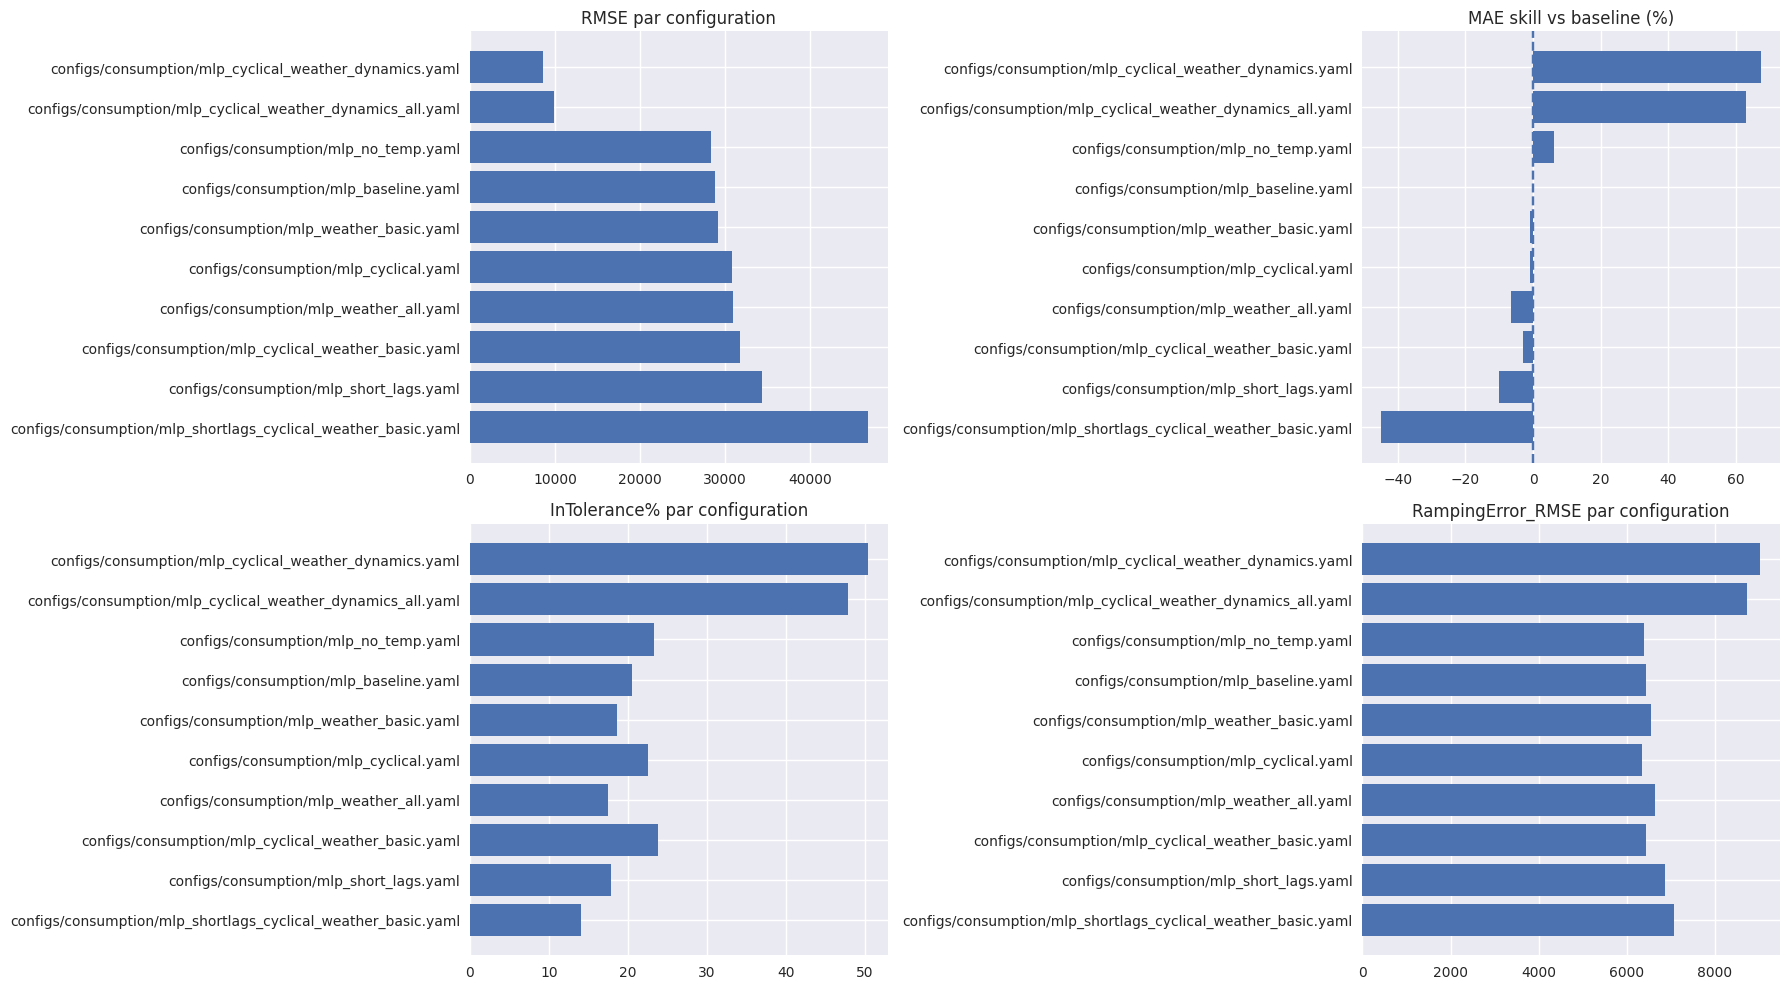

In [11]:
plot_df = bench.copy()
plot_df = plot_df.sort_values('RMSE' if 'RMSE' in plot_df.columns else 'MAE', ascending=True)
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.ravel()

if 'RMSE' in plot_df.columns:
    axes[0].barh(plot_df['config_name'], plot_df['RMSE'])
    axes[0].set_title('RMSE par configuration')
    axes[0].invert_yaxis()

if 'MAE_skill_vs_baseline_%' in plot_df.columns:
    axes[1].barh(plot_df['config_name'], plot_df['MAE_skill_vs_baseline_%'])
    axes[1].set_title('MAE skill vs baseline (%)')
    axes[1].axvline(0, linestyle='--')
    axes[1].invert_yaxis()

if 'InTolerance%' in plot_df.columns:
    axes[2].barh(plot_df['config_name'], plot_df['InTolerance%'])
    axes[2].set_title('InTolerance% par configuration')
    axes[2].invert_yaxis()

if 'RampingError_RMSE' in plot_df.columns:
    axes[3].barh(plot_df['config_name'], plot_df['RampingError_RMSE'])
    axes[3].set_title('RampingError_RMSE par configuration')
    axes[3].invert_yaxis()

plt.tight_layout()
plt.show()


## 6. Sélection automatique des meilleurs runs à analyser ensuite

In [12]:
best_global = top_by(bench, ['RMSE', 'MAE', 'SMAPE%'], n=1)
best_tolerance = bench.sort_values('InTolerance%', ascending=False).head(1) if 'InTolerance%' in bench.columns else pd.DataFrame()
best_ramping = bench.sort_values('RampingError_RMSE', ascending=True).head(1) if 'RampingError_RMSE' in bench.columns else pd.DataFrame()

selected = pd.concat([best_global, best_tolerance, best_ramping], axis=0).drop_duplicates()
selected = selected[[c for c in ['config_name', 'run_id', 'run_dir', 'exports_dir'] if c in selected.columns] + available_metrics]
selected


,config_name,run_id,MAE,RMSE,Bias(ME),MAPE%,SMAPE%,InTolerance%,P95AbsError,P99AbsError,UnderShare%,OverShare%,Under_MAE,Over_MAE,CorrAbsErr_vs_Real,RampingError_RMSE
0,configs/consumption/mlp_cyclical_weather_dynam...,consumption_mlp_20260410T050823Z,"6,459.650877","8,596.642852","-1,458.176664",2.644413,2.664803,50.343511,"17,649.853125","24,546.609688",53.206107,46.793893,"7,440.713112","5,344.152707",0.277475,"9,022.701263"
4,configs/consumption/mlp_cyclical.yaml,consumption_mlp_20260410T050718Z,"20,069.883668","30,740.222171","-12,977.416815",7.581370,8.047734,22.557252,"74,316.365625","114,006.839375",66.183206,33.816794,"24,966.530353","10,486.604490",0.396937,"6,331.255537"


In [13]:
# Sauvegarde optionnelle pour réutilisation dans le notebook détaillé
selection_path = PROJECT_ROOT / 'artifacts' / 'benchmarks' / 'selected_runs_for_detailed_analysis.csv'
selection_path.parent.mkdir(parents=True, exist_ok=True)
selected.to_csv(selection_path, index=False)
print('Sélection sauvegardée dans:', selection_path)


Sélection sauvegardée dans: /home/khalid/cours/m1/SmartGrid_Project/smart-grid/artifacts/benchmarks/selected_runs_for_detailed_analysis.csv


## 7. Conclusion à raconter

- **Top global** : meilleure précision brute (`RMSE`, `MAE`, `SMAPE%`)
- **Top tolerance** : meilleur comportement opérationnel (`InTolerance%`)
- **Top ramping** : meilleure gestion des variations rapides (`RampingError_RMSE`)
- **Baseline** : sert de point zéro pour mesurer le gain réel

Utilise ensuite le `run_id` ou le `run_dir` retenu dans le notebook détaillé.
